# DS 3025 Project 4: Neural Network From Scratch


**Name:** Max Guryan (rhk2dx)

**Type the Honor Pledge Here:** 
On my honor, I have not given nor received unauthorized aid on this assignment.

In this project, you will build a neural network from scratch and use it to practice evidence-based model comparison.

This project has two main goals:

1. **Understand neural network training**
   - Build the core pieces of a neural network yourself
   - See how forward propagation, backpropagation, and gradient-based updates work together

2. **Practice structured experimentation**
   - Compare models using evidence
   - Document what you changed, what happened, and what you learned

## Project roadmap

You will complete the project in six parts:

- **Part 1:** Build and verify a **1-hidden-layer** neural network
- **Part 2:** Extend that model into a **2-hidden-layer** neural network
- **Part 3:** Run structured experiments on the **2-hidden-layer** model
- **Part 4:** Document **6 experimental runs** in a tuning log
- **Part 5:** Defend your best model using evidence
- **Part 6:** Answer short comprehension questions

## Project expectations

Most of your grade comes from:
- correct implementation
- clear reasoning
- disciplined experimentation
- evidence-based interpretation

The hidden model-ranking component is worth **10 points out of 100**. It matters, but it does **not** dominate the project.

To keep grading fair and reproducible, please follow these rules throughout the notebook:

- Use **seed = 42** everywhere.
- Do **not** edit cells marked **DO NOT EDIT**.
- Do **not** rename the function headers provided in the notebook.
- Build only from the code and imports already provided.
- Do **not** add features, columns, outside data, or your own test set.
- Your final ranked model must be reported in the **final configuration dictionary** near the end of the notebook.
- Your final ranked model must match **one of your 6 logged runs** from Part 4.
- If the final configuration dictionary is missing, malformed, or does not match one of your 6 logged runs, you will receive **0/10** for the ranking component.

Before submitting, restart your Colab runtime and run the notebook from top to bottom. Your submitted results should be reproducible.

## How to think about model evaluation

In this project, you will track both **cost** and **accuracy**.

- **Accuracy** tells you how often the model predicts the correct class.
- **Cost** tells you how wrong the model’s predictions are numerically on average.

These two metrics are related, but they are not identical, so both are useful when evaluating training.

The output node predicts the probability of **white wine**, because the code uses `red = 0` and `white = 1`.

## Code guide

A few notebook cells are intentionally protected so grading stays reproducible.

- Cells labeled **DO NOT EDIT** should be left unchanged.
- Keep the function headers exactly as written. You should fill in the body of each function, not rename it.
- In this notebook, the `test()` and `test_2()` functions should **return numeric accuracy values** so they can be reused in analysis and grading.
- In **Part 3** and **Part 4**, your main evaluation metrics are:
  - **final train cost**
  - **final test cost**
  - **test accuracy**
  - **runtime**
- For your **final best model**, you should also compare **train accuracy** and **test accuracy** so you can comment on possible overfitting.
- In **Part 4**, you must document **6 runs** in the markdown log. You may do additional private runs, but your final submitted model must be one of the 6 documented runs.


### Tips for Success on This Project

- Use `print()` statements strategically to debug shapes, intermediate outputs, and final metrics.
- Build and test small helper functions first before trying to run the full training loop.
- Check matrix shapes carefully before matrix multiplication. If something is not working, print `.shape` and verify that your dimensions line up. In some cases, you may need to transpose with `.T`.
- If your results look very different from what you expect, first check:
  - your random seed
  - your matrix shapes
  - your averaging/division steps for cost and gradients
  - whether you used the correct training data inside `train()` and `train_2()`
- Use the structured baseline runs in the notebook as debugging checkpoints before moving on to experiments.
- The `test()` and `test_2()` functions should return numeric accuracy values so you can reuse them in tables, comparisons, and final evaluation.
- Make sure your cost tracking matches the notebook instructions. In this project, you should report train and test curves on an **MSE scale**, so be careful about when you divide by the number of examples.
- Use the experiment log in Part 4 to stay organized. Document what you changed, what happened, and what you learned after each run.
- If you get stuck on Python syntax or an error message, look it up. Debugging is part of the project.

In [2]:

#### DO NOT EDIT ####
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

In [3]:

#### DO NOT EDIT ####
seed = 42
np.random.seed(seed)

## Load Data

For this project, we're using a new dataset to classify wine type between red and white. We have the following measurements of each wine "subject" (`fixed acidity`, `volatile acidity`, `residual sugar`, `chlorides`, `alcohol`, `quality`). 

Our goal is to predict the type of wine (red or white). This means we are dealing with a binary classification problem. Below is the code to load in the data sets to X and Y. Do **not** change the code below.

### Important note
In this project:
- red wine = 0
- white wine = 1

So the output node should be interpreted as the model's estimate that an example is **white wine**.


In [4]:

#### DO NOT EDIT ####
red = pd.read_csv(
    'https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/refs/heads/master/winequality-red.csv',
    sep=';'
)
white = pd.read_csv(
    'https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/refs/heads/master/winequality-white.csv',
    sep=';'
)

# Use the same reduced sample as the original project
red = red.sample(200, random_state=seed).copy()
white = white.sample(200, random_state=seed).copy()

# Keep the same six-feature setup
drop_cols = ['density', 'pH', 'citric acid', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']
red.drop(drop_cols, axis=1, inplace=True)
white.drop(drop_cols, axis=1, inplace=True)

# add columns for classification
red['type'] = 0
white['type'] = 1

# combine the data frames
wine = pd.concat([red, white], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)

# Now separate X and Y
X = wine.drop(columns=['type'])
Y = wine['type']

print(X.head())
print(Y.value_counts())

   fixed acidity  volatile acidity  residual sugar  chlorides  alcohol  \
0            8.7              0.31           14.35      0.044      8.7   
1            7.1              0.34            1.40      0.174      9.3   
2           10.2              0.67            1.90      0.054     10.0   
3            6.4              0.14            1.20      0.034     11.5   
4           12.7              0.60            2.80      0.075     11.4   

   quality  
0        5  
1        5  
2        5  
3        7  
4        5  
type
1    200
0    200
Name: count, dtype: int64


## Part 1: Build a 1-hidden-layer network

### Goal
Build the simplest trainable neural network in this project so you can clearly see how the pieces fit together.A 1-hidden-layer model is easier to read and debug than a deeper network. You will use this part to understand the mechanics first. After that, the project shifts to the **2-hidden-layer model**.


### Task: split the data and standardize the features

Convert the pandas objects to NumPy arrays, split into train and test sets, and standardize the features using **training data only**.

This is important because the test set should be treated like unseen data.  
You can use the training mean and standard deviation to scale both sets, but you should not use test-set statistics to define the scaling.


In [5]:
# Convert X and Y from pandas to numpy arrays
X_array = X.to_numpy()
Y_array = Y.to_numpy()
# Train/test Split

X_train, X_test, Y_train, Y_test = train_test_split(
    X_array, Y_array, test_size=0.2, random_state=seed
    )

# Standardize using training data only
train_mean = X_train.mean(axis = 0)
train_std = X_train.std(axis =0)

X_train = (X_train - train_mean)/train_std
X_test = (X_test - train_mean)/train_std

# Reshape Y_train and Y_test to nx1 matrices
 
Y_train = Y_train.reshape(-1, 1)
Y_test = Y_test.reshape(-1, 1)

#### DO NOT ADJUST ####
# Check X Train and Test Shapes
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Y_train shape:', Y_train.shape) #notice how there's a 1 in the column space after reshaping
print('Y_test shape:', Y_test.shape) #notice how there's a 1 in the column space after reshaping

X_train shape: (320, 6)
X_test shape: (80, 6)
Y_train shape: (320, 1)
Y_test shape: (80, 1)


### Task: define the network dimensions

For the 1-hidden-layer model:


- `input_nodes` should match the number of features
- `hidden_nodes` is a tunable hyperparameter
- `output_nodes` because this is binary classification

This cell sets the dimensions that later functions will rely on.

What is going to be your number of output nodes and input node - Why? (be careful with your reasoning for your output nodes)

**Answer:**

The number of input nodes is going to be 6 because the input nodes should be equal to the number of features in the dataset and we have 6 features in this dataset. We only need one output node. The output is going to tell us the probability that the wine is classified as white "P(White)". This value can directly tell us the probability of the wine being red "P(Red)" because P(Red) = 1 - P(White). 

In [6]:

input_nodes = 6
hidden_nodes = 1 #this will change once we move past a 1-hidden-layer model
output_nodes = 1

### Task: define helper functions

In this block, you will define:
- activation functions
- activation derivatives
- helper wrappers that switch between activations
- the cost function

These functions are reused throughout the rest of the project, so keep them simple and consistent. Pay close attention to the formulas and directions. **Do not change the names of these functions.**


##### Create a function called `sigmoid(x)`.

This will be one of your **activation functions** that takes some vector `x` and returns the sigmoid of the vector. The `sigmoid` function can be written as:

\begin{gather}
  \sigma(x) = \frac{1}{1 + e^{-x}}
\end{gather}

In [7]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

##### Create a function called `sigmoid_derivative(x)`.

This function will calculate the derivative of the activation function for backpropogation in the network at some point, `x`. The function should return the derivative of the sigmoid function at that point. The derivative of the Sigmoid function is written as:

\begin{gather}
  \sigma^\prime (x) = \sigma(x) * (1 - \sigma(x))
\end{gather}

In [8]:

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

##### Create a function called `relu(x)`.

This function will calculate and return the `ReLU` of some input value `x`. The ReLU function can be written as:

\begin{gather}
  \sigma(x) = \begin{cases} x, & x > 0 \\ 0, & x \leq 0 \end{cases} = max(0, x)
\end{gather}

In [9]:

def relu(x):
    return np.maximum(0, x)

##### Create a function called `relu_derivative(x)`.

This will calculate the derivative of the `ReLU` function for the given input. The derivative of ReLU can be written as:

\begin{gather}
  \sigma^{\prime}(x) = \begin{cases} 1, & x > 0 \\ 0, & x \leq 0 \end{cases}
\end{gather}

In [10]:

def relu_derivative(x):
    return (x > 0).astype(float)

##### Create a new function called `tanh()`.

There are other activation functions than just Sigmoid and ReLU. Note: for this question, and this question only, you are restricted to only using the `np.exp()` function from Numpy. Do **not** directly use `np.tanh()` for this question.

Hint: The equation for the hyperbolic tangent is:

\begin{gather}
  \sigma(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
\end{gather}

In [11]:

def tanh(x):
    return (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))

##### Define a `tanh_derivative()` function.

The derivative of the hyperbolic tangent is the **square of the hyperbolic secant**.  
Do **not** directly use `np.tanh()` for this question.


you can write the derivative as

$$
\frac{d}{dx}\tanh(x)=\left(\frac{2}{e^x+e^{-x}}\right)^2
$$

In [12]:
def tanh_derivative(x):
    return (2/(np.exp(x) + np.exp(-x))) ** 2

##### Plot your activation function for $X \in [-10, 10]$ with 100 data points. This is a way to confirm that your function behaves how the hyperbolic tanh does.

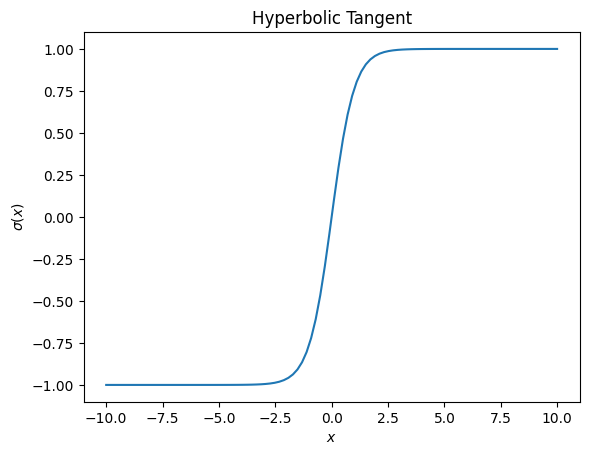

In [13]:
# create X vector as described above to define the first parameter of the plot
X = np.linspace(-10, 10, 100)
# use the function you just created for tanh to define the second parameter of the plot

tanh_vals = tanh(X)

#### DO NOT ADJUST ####
plt.plot(X, tanh_vals)
plt.title(r'Hyperbolic Tangent')
plt.xlabel(r'$x$')
plt.ylabel(r'$\sigma(x)$')
plt.show()

##### Create a function called `ActivationFxn(x, activation_type)`.

This will be a function that combines the two activation functions that you defined above. Given the activation type determined by `activation_type` , the function should calculate the activation function of the value `x`. 

Hint: You can use `if` statements to check for what type of `activation_type` the user wants. Make sure to have a condition for when the provided `activation_type` is not valid.

In [14]:
# Combine your activation functions into one function
def ActivationFxn(x, activation_type):
    # TODO: write your code here
    if activation_type == 'sigmoid':
        return sigmoid(x)
    elif activation_type == 'relu':
        return relu(x)
    elif activation_type == 'tanh':
        return tanh(x)
    else:
        raise ValueError(f"Your input {activation_type} must be from this list: ['sigmoid', 'relu', 'tanh']")


#####  Create a function called `ActivationFxnDerivative(x, activation_type)`.

This will be a function that combines the two activation functions derivatives that you defined above. Given the activation type determined by `activation_type`, the function should calculate the activation function derivative of the value `x`. 

Hint: You can use `if` statements to check for what type of `acitvation_type` the user wants. Make sure to have a condition for when the provided `activation_type` is not valid.

In [15]:

def ActivationFxnDerivative(x, activation_type):
    # TODO: write your code here
    if activation_type == 'sigmoid_derivative':
        return sigmoid_derivative(x)
    elif activation_type == 'relu_derivative':
        return relu_derivative(x)
    elif activation_type == 'tanh_derivative':
        return tanh_derivative
    else: 
        raise ValueError(f"Your input {activation_type} must be from this list ['sigmoid_derivative', 'relu_derivative', 'tanh_derivative']")

### Task: Define the cost function

This project uses a squared-error style cost:

- it gives the training loop a numerical objective to reduce
- it gives you the train/test cost curves you will interpret later
- it works together with gradient-based updates

You should not think of cost and accuracy as the same thing:
- **Accuracy** asks whether a prediction is correct after thresholding
- **Cost** measures how far the raw prediction is from the target

We use cost in the project because training needs a quantity to minimize, and the cost curves help us judge whether learning is stable.


For this function, `y` is the true wine type and `y_hat` is the predicted probability of a **white wine**. The equation you should use is:

\begin{gather}
  \text{cost}(x) = \sum (y - y\_\text{hat})^2
\end{gather}


In [16]:

def cost(y, y_hat):
    # TODO: write your code here
    return np.sum((y - y_hat) ** 2)

### Task: implement the 1-hidden-layer network functions

These are the major functions that make the model work:
- weight initialization
- forward propagation
- output generation
- gradient computation
- training
- accuracy evaluation

As you write these, keep the roles separate:
- **forward propagation** computes predictions
- **gradient functions** compute update information
- **training** repeats those steps over many epochs


### Task: initialize the 1-hidden-layer parameters

Create a function that initializes the values of the weights `W1`, `W2` and biases `b1`, `b2`.

Use the provided `seed` so that results stay reproducible.

**NOTE**: make sure to re-run `GenerateAllWeights` each time you train the network (otherwise `train` function will have edited the matices and you want them to start random)


In [17]:

def GenerateAllWeights(input_nodes, hidden_nodes, output_nodes, seed):
    W1 = np.random.randn(hidden_nodes, input_nodes)
    b1 = np.zeros((hidden_nodes , 1))
    W2 = np.random.randn(output_nodes, hidden_nodes)
    b2 = np.zeros((output_nodes, 1))
    return W1, b1, W2, b2

### Task: implement forward propagation for the 1-hidden-layer model

This function should:
- take one input example
- compute the hidden-layer values
- compute the output-layer values
- return the intermediate quantities needed later for gradient computation

 For example, the output of the 1st pass (input to hidden) could be called `z1` for before activation and `a1` = $(a_{11}, a_{12}, a_{13})$ for after activation. Likewise, the 2nd pass (output from the hidden to output) could be called `z2` before activation and `a2` = $(a_{21})$ after.


In [18]:

def forward_propagation(x, activation_type):
    z1 = W1 @ x + b1
    a1 = ActivationFxn(z1, activation_type)
    z2 = W2 @ z1 + b2
    a2 = ActivationFxn(z2 , activation_type)
    return z1, a1, z2, a2

### Task: Define an `output()` helper for batch prediction

Write a function that generates predictions for every row in a data matrix, `X`.

Your function should:

1. Loop over each row of `X`
2. Reshape that row into a column vector so it can be passed through the network
3. Call your `forward_propagation()` function on that sample
4. Catch all returned values from `forward_propagation()`
5. Save the final output from the output layer, `a2`, into a list

**Sanity check:** the number of outputs should match the number of rows in `X`.

In [19]:

def output(X, activation_type):
    predictions = []
    for i in range(X.shape[0]):
        x = X[i].reshape(-1, 1)
        z1, a1, z2, a2 = forward_propagation(x, activation_type)
        predictions.append(a2)
    return predictions

### Task: Compute gradients for the 1-hidden-layer model

Write a function that computes the gradients for all weights and biases in the 1-hidden-layer neural network.

The inputs to this function are the current sample, the true label, and the intermediate values from forward propagation. Use these values to compute the gradient terms needed to update the model parameters.

Your function should return:
- `dW1`
- `db1`
- `dW2`
- `db2`

For the gradient formulas, refer back to Labs 11 and 12.

In [21]:
def gradient(x, y, a1, a2, z1, z2, activation_type):
    dz2 = (a2 - y) * ActivationFxnDerivative(z2, activation_type)
    dW2 = dz2 @ a1.T
    db2 = dz2

    dz1 = (W2.T @ dz2) * ActivationFxnDerivative(z1, activation_type)
    dW1 = dz1 @ x.T
    db1 = dz1

    return dW1, db1, dW2, db2

### Task: implement the 1-hidden-layer training loop

This is the function that brings the model together. The function should apply each of the helper functions you defined before in the correct order. The function should return the cost values for both the training and testing data in lists.

Across many epochs, it should:
- run forward propagation
- accumulate training cost
- accumulate gradients
- update parameters
- record train and test cost curves

Two details matter here:
- average the accumulated gradients by `x_train.shape[0]`
- report the **average cost per example** so your train and test curves are both shown as MSE and are comparable even though the train and test sets have different sizes


In [ ]:

def train(x_train, y_train, x_test, y_test, learning_rate, epochs, activation_type):
    return

##### Task: Create a function called `test()` for your 1-hidden-layer network.

For pedagogical consistency, we will use the name `test()` here.  
Unlike a print-only checkpoint, this version should **return a numeric accuracy value** so it can be reused in analysis, tables, and grading later.


In [ ]:
def test(inputs, outputs, activation_type):
    # return the accuracy as a float
    return

### Task: run and inspect the 1-hidden-layer baseline

Use your completed functions to train a baseline model.

Next, we will put all of our functions together to actually train the neural network. Start by defining the number of epochs and the learning rate. For this part, use values of `hidden_nodes=3`, `epochs=500`, `learning_rate=0.1`, and `activation_type = 'sigmoid'`. Once the parameters are set, go ahead and define your weights, train the network, and plot the MSE for the training and testing set respectively.

### What to look for
- Do the train and test cost curves decrease?
- Are the predictions better than random guessing?
- Does the code run cleanly from start to finish?

This is your first full end-to-end check that the training pipeline works.


In [ ]:
# Initialize weights and biases

# Train the model and get the train and test costs

## DO NOT ADJUST ##
max_cost = max(np.max(train_cost_1), np.max(test_cost_1))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(epochs), train_cost_1, label='Train Cost')
plt.plot(np.arange(epochs), test_cost_1, label='Test Cost')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title(f'MSE For Train vs Test Data ({epochs} Epochs) - 1-hidden-layer baseline')
plt.ylim([0, max_cost * 1.05])   # add 5% padding
plt.legend()
plt.show()

##### Task: Test the network after training

Now that you've trained the model, use your numeric-return `test()` function on the training data and the held-out test data.


In [ ]:
#Print the train and test accuracies


## Part 2: Extend to a 2-hidden-layer network

In this part, you will extend your 1-hidden-layer model into a **2-hidden-layer neural network**. From this point on, the 2-hidden-layer model is the main model you will use for the rest of the project, including Part 3, Part 4, and the final ranked model.

Real neural networks usually involve multiple hidden transformations, so this part moves you closer to the kind of model structure used in practice. The training logic stays the same, but now you must track information and gradients through one additional hidden layer.

### Task: Define the 2-hidden-layer dimensions

Set the number of nodes in:
- the first hidden layer
- the second hidden layer
- the output layer

The two hidden widths can vary independently in your experiments.

### Task: Create the 2-hidden-layer versions of your functions

To support the extra hidden layer, you will create new versions of your earlier functions using the suffix `_2`.

- `GenerateAllWeights()` → `GenerateAllWeights_2()`
- `forward_propagation()` → `forward_propagation_2()`
- `output()` → `output_2()`
- `gradient()` → `gradient_2()`
- `train()` → `train_2()`
- `test()` → `test_2()`

**Important:** when working with the 2-hidden-layer model, make sure you use the `_2` versions consistently. If you accidentally mix the original functions with the new ones, you will likely run into shape or variable errors.

In [280]:
input_nodes = X_train.shape[1]
first_hidden_nodes = 3
second_hidden_nodes = 3
output_nodes = 1

### Task: Initialize parameters for the 2-hidden-layer model

Create the weight matrices and bias vectors needed for a network with two hidden transformations that returns three weights and biases.


In [ ]:

def GenerateAllWeights_2(input_nodes, first_hidden_nodes, second_hidden_nodes, output_nodes, seed):
    # TODO: write your code here
    return

### Task: Implement forward propagation for the 2-hidden-layer model

The logic is the same as before, but now information passes through:
- hidden layer 1
- hidden layer 2
- output layer

Make sure you return the intermediate values needed for backpropagation.


In [282]:

def forward_propagation_2(x, activation_type):
    # TODO: write your code here
    pass

### Task: Define the batch output helper for the 2-hidden-layer model

This helper should generate model outputs for a whole dataset, not just one example.


In [283]:

def output_2(X, activation_type):
    # TODO: write your code here
    pass

### Task: Compute gradients for the 2-hidden-layer model

This is the deeper backpropagation step.

You now need to carry gradient information backward through:
- the output layer
- hidden layer 2
- hidden layer 1


In [284]:

def gradient_2(x, y, a1, a2, a3, z1, z2, z3, activation_type):
    # TODO: write your code here
    pass

### Task: Implement the 2-hidden-layer training loop

This function is the main training engine for the rest of the project.

It should return the train and test cost curves so you can later compare stability, convergence, and possible overfitting.

As in Part 1:
- average the accumulated gradients by `x_train.shape[0]`
- report the **average cost per example** so your train and test curves are both shown as MSE


In [285]:

def train_2(x_train, y_train, x_test, y_test, learning_rate, epochs, activation_type):

    # Correction carried into the notebook:
    # average by x_train.shape[0], not by X.shape[0]
    # TODO: write your code here
    pass

### Task: create a `test_2()` function for the 2-hidden-layer model

As before, this function should **return** a numeric accuracy value so it can be reused in analysis, comparison tables, and grading.


In [ ]:
def test_2(inputs, outputs, activation_type):

    # return the accuracy as a float
    # TODO: write your code here
    pass

### Task: run the 2-hidden-layer baseline Now that you've defined your functions, 

Train your new 2 layer network. Plot the training and testing errors. Use parameters of `learning_rate=0.1`, `epochs=500`, and `activation_type = 'sigmoid'`.

Make sure to name your outputs from train_2 `train_cost_2` and `test_cost_2` so as not to overwrite your train_cost and test_cost values from your 1-layer model! (If you do overwrite these values, make sure to go back and re-run your 1 hidden layer model training code chunk)

This is your first full check that the deeper model works correctly before you start the experiment sections.


In [ ]:

learning_rate =
epochs =
activation_type = 
first_hidden_nodes = 
second_hidden_nodes = 

# Initialize weights and biases

# Train the model and get the train and test costs

#### DO NOT ADJUST ####
plt.plot(np.arange(epochs), train_cost_2, label = 'Train Cost', color = 'dodgerblue')
plt.plot(np.arange(epochs), test_cost_2, label = 'Test Cost', color = 'firebrick')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title(f'MSE For Train vs Test Data ({epochs} Epochs)')
plt.legend()
plt.show()

#### Task: Calculate your train and test accuracy using your `test_2()` function.

In [ ]:
#Print the train and test accuracies

#### Plot the train and test errors for both of your models: 1 hidden layer vs 2 hidden layers. Just run this code chunk below. There is no need for you to adjust the code.

In [ ]:
#### DO NOT EDIT ####
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(train_cost_1)), train_cost_1, label='1-layer Train Cost')
plt.plot(np.arange(len(test_cost_1)), test_cost_1, label='1-layer Test Cost')
plt.plot(np.arange(len(train_cost_2)), train_cost_2, '--', label='2-layer Train Cost')
plt.plot(np.arange(len(test_cost_2)), test_cost_2, '--', label='2-layer Test Cost')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('1-hidden-layer vs 2-hidden-layer comparison')
plt.legend()
plt.show()

#### Task: Compare your 1-hidden-layer and 2-hidden-layer models from the plots above in words below.

- Compare the train and test accuracy values you printed earlier.
- Compare how the train/test cost curves behave for the two models.
- Based on this evidence, what changed when you added a second hidden layer? did they overfit/underfit?

**Answer:**

## Part 3: Structured experiments on the 2-hidden-layer model

### Goal
Run a small set of controlled experiments so you can learn something useful before Part 4.

Use the **2-hidden-layer model only** in this section.

We will be walking you through 4 different experiments that test while keeping the other parameters constant:
- Our Baseline model
- Activation Functions: `'sigmoid'`, `'relu'`, and `'tanh'`
- Learning Rates: `0.5`, `0.1`, `0.01`, and `0.001`
- \# of Hidden Nodes


### Rules
- Keep **epochs fixed at 500** in Part 3.
- Use the **same activation function in both hidden layers**.
- Record:
  - final train cost
  - final test cost
  - test accuracy
  - runtime

### Why this section exists
These experiments are not here just to fill a table.  
They are meant to give you evidence that will guide your later tuning decisions.

Important: For a fair comparison, each experiment should start from a fresh set of randomly initialized weights and biases. In the protected experiment helper below, this reset happens automatically at the start of each run.


#### Task: Complete experiment function below using the two layer functions you created above

In [ ]:

def run_two_layer_experiment(first_hidden_nodes, second_hidden_nodes, activation_type, learning_rate, epochs, seed=42):
    global W1, W2, W3, b1, b2, b3

    # Initialize weights and biases for the 2-layer model

    start_time = time.time()
    # Train the model and get the train and test costs

    elapsed = time.time() - start_time

    # Get the train and test accuracies

    # Return the results as a dictionary
    return {
        'activation': 
        'learning_rate': ,
        'epochs': ,
        'hidden_nodes_1': ,
        'hidden_nodes_2': ,
        'train_cost': ,
        'test_cost': ,
        'train_accuracy': ,
        'test_accuracy': ,
        'runtime': ,
        'train_curve': ,
        'test_curve': 
    }

### Task: run the Part 3 baseline experiment

Start with one fixed 2-hidden-layer baseline so that later experiments have a clear reference point.


In [ ]:
# Now run the same experiment with ReLU and tanh activations, and compare the results in a single plot. 

# Create list to store part3_results

# Run the baseline 2-layer sigmoid model first with the method given 

#append the baseline result to the part3_results list

## DO NOT ADJUST ##
plt.figure(figsize=(8, 4))
plt.plot(baseline_result['train_curve'], label='Train Cost')
plt.plot(baseline_result['test_curve'], label='Test Cost')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Part 3 baseline: 2-layer sigmoid model')
plt.legend()
plt.show()

print('Test accuracy:', baseline_result['test_accuracy'])

### Task: Activation experiment: sigmoid vs relu vs tanh

Train the same 2-hidden-layer model with the three activation functions (`sigmoid`, `relu`, and `tanh`).

After you run the code and review the plot/table, answer these two questions:
1. Which activation gave the best final **test accuracy**?
2. Which activation looked the most stable on the **test-cost curve**?


Train your model using the 3 different activation functions (`sigmoid`, `relu`, `tanh`) that you have created. For each activation function, record and report the training cost, testing cost, and runtime. **Make sure to append your new values to your lists for your table in the right spots!**


In [ ]:
# Now run the same experiment with ReLU and tanh activations, and compare the results in a single plot.

# Create list to store results

# Loop through the three activation types and run the experiment for each, storing the results in the activation_results list

# append the result to the activation_results list and the part3_results list


## DO NOT ADJUST ##
plt.figure(figsize=(11, 4.5))
all_activation_curves = np.vstack([np.array(r['test_curve']) for r in activation_results])
ymin = float(all_activation_curves.min())
ymax = float(all_activation_curves.max())
ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

for result in activation_results:
    plt.plot(result['test_curve'], linewidth=2, label=f"{result['activation']} test cost")

plt.xlim(0, 500)
plt.ylim(max(0, ymin - ypad), ymax + ypad)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Activation experiment (2-layer model)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['train_curve', 'test_curve']}
    for r in activation_results
])


### Activation experiment interpretation

**Question 1:** Which activation gave the best final **test accuracy**?

**Answer:**

**Question 2:** Which activation looked the most stable on the **test-cost curve**?

**Answer:**

### Task: Learning-rate experiment

Compare your model with different learning rates. The learning rates you test should be `0.5`, `0.1`, `0.01`, and `0.001`.

After you run the code and review the plot/table, answer these two questions:
1. Which learning rate looked too aggressive or unstable?
2. Which learning rate gave the best balance of learning speed and stability?


In [ ]:
# make a new list to store the learning rate results

# Loop through the four learning rates and run the experiment for each, storing the results in the lr_results list


    # append the result to the lr_results list and the part3_results list
   

##  DO NOT ADJUST ##
plt.figure(figsize=(11, 4.5))
all_lr_curves = np.vstack([np.array(r['test_curve']) for r in lr_results])
ymin = float(all_lr_curves.min())
ymax = float(all_lr_curves.max())
ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

for result in lr_results:
    plt.plot(result['test_curve'], linewidth=2, label=f"lr={result['learning_rate']}")

plt.xlim(0, 500)
plt.ylim(max(0, ymin - ypad), ymax + ypad)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Learning-rate experiment (2-layer model)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['train_curve', 'test_curve']}
    for r in lr_results
])


### Learning-rate experiment interpretation

**Question 1:** Which learning rate looked too aggressive or unstable?

**Answer:**

**Question 2:** Which learning rate gave the best balance of learning speed and stability?

**Answer:**

### Task: hidden-width experiment

Now vary the two hidden-layer widths to see how model capacity affects performance.

This is where you can start noticing whether extra flexibility helps, plateaus, or risks worse generalization.

Compare your model with different numbers of hidden nodes.  For each number of hidden nodes, calculate and report the training cost, testing cost, and runtime. **Note:** This should look very similar to what you did in the previous question and for activation functions. **Make sure to append your new values to your lists for your table in the right spots!**


In [ ]:
# Now run the same experiment with different hidden layer widths, and compare the results in a single plot.
# Create list to store results
# Loop through the four width combinations and run the experiment for each, storing the results in the width_results list

# append the result to the width_results list and the part3_results list
   

## DO NOT ADJUST ##
plt.figure(figsize=(11, 4.5))
all_width_curves = np.vstack([np.array(r['test_curve']) for r in width_results])
ymin = float(all_width_curves.min())
ymax = float(all_width_curves.max())
ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

for result in width_results:
    label = f"H1={result['hidden_nodes_1']}, H2={result['hidden_nodes_2']}"
    plt.plot(result['test_curve'], linewidth=2, label=label)

plt.xlim(0, 500)
plt.ylim(max(0, ymin - ypad), ymax + ypad)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Hidden-width experiment (2-layer model)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['train_curve', 'test_curve']}
    for r in width_results
])


### Hidden-width experiment interpretation

**Question 1:** Which hidden-width setting gave the best final test accuracy?

**Answer:**

**Question 2:** Did increasing width always help, or did the gains start to level off?

**Answer:**

### Task: Combine the Part 3 results into one summary table

This table should make it easier to compare all of the structured experiments at once. Print out your Final Table using the columns you generated in each of your experiments above** 

| Activation Function | Learning Rate | Epochs | Hidden Nodes | Train Cost | Test Cost| Train Accuracy | Test Accuracy |Runtime |
| --------- |  --------- |  --------- |  --------- |  --------- |  ---------|  --------- | ---------|  --------- |
| Sigmoid | 0.1  | 500 | 3 | ?  | ? | ? |

## Part 4: Limited-budget experiment log

### Goal
Document a sequence of tuning decisions instead of treating model selection like random guessing.

You must document **6 runs** in the log below.

For each run, answer:
- What are you changing?
- Why are you changing it?
- What do you expect this run to help you learn?

Then report:
- final train cost
- final test cost
- test accuracy
- runtime
- what you learned
- what run it suggests next

You may do additional private runs if you want, but the **final model you submit must be one of the 6 logged runs below**.

**Reminder:** if your final configuration dictionary is missing, malformed, or does not match one of these 6 logged runs, the ranking component receives **0/10**.


### Experiment log template (student-facing version should edit this manually)

Use the columns below consistently.

- **Hidden Layer 1 Nodes** = the number of neurons in the first hidden layer
- **Hidden Layer 2 Nodes** = the number of neurons in the second hidden layer

| Run | Hidden Layer 1 Nodes | Hidden Layer 2 Nodes | Activation | Learning Rate | Epochs | What are you changing? | Why this run? | What do you expect to learn? | Final Train Cost | Final Test Cost | Test Accuracy | Runtime | What did you learn? | What should come next? |
|---|---:|---:|---|---:|---:|---|---|---|---:|---:|---:|---:|---|---|
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |
| |  |  |  |  |  |  |  |  |  | ? | ? | ? | ? | ? | ? |


### Task: encode the same 6 runs in Python

The dictionary list below should match the six rows in your markdown log above.
Keep the run numbers and settings aligned so the grader can verify that your final chosen model came from one documented run.


In [ ]:
logged_runs = [
    {'run': 1 , 'hidden_nodes_1': , 'hidden_nodes_2': , 'activation': , 'learning_rate': , 'epochs': },
    {'run': 2, 'hidden_nodes_1': , 'hidden_nodes_2': , 'activation': , 'learning_rate': , 'epochs': },
    {'run': 3, 'hidden_nodes_1': , 'hidden_nodes_2': , 'activation': , 'learning_rate': , 'epochs': },
    {'run': 4 , 'hidden_nodes_1': , 'hidden_nodes_2': , 'activation': , 'learning_rate': , 'epochs': },
    {'run': 5 , 'hidden_nodes_1': , 'hidden_nodes_2': , 'activation': , 'learning_rate': , 'epochs': },
    {'run': 6 , 'hidden_nodes_1': , 'hidden_nodes_2': , 'activation': , 'learning_rate': , 'epochs': },  

logged_runs


### Task: run the 6 logged experiments and review the results table

This cell evaluates the exact six configurations from your log.  
Make sure the table output matches the run settings you documented above.


In [ ]:
# Now run the experiments for the logged runs and compile the results into a table. Print table


### Identify the best logged run numerically

This cell finds the strongest logged run according to **test accuracy**.  
Later, your written defense should explain *why* that run is best using more than just one number.


In [ ]:
# Identify the best run based on test accuracy and print its configuration and results.
best_run = max(part4_results, key=lambda r: r['test_accuracy'])
best_run

### Task: visualize and interpret the best logged run

Use the train/test cost curves and the train/test accuracy values below to judge whether this model looks strong, stable, and reasonably well-generalized.


In [ ]:
# Plot the train and test cost curves for the best run.


# Print the train and test accuracy for the best run.



## Part 5: Defend your best model

In this section, you should justify your final choice using evidence.

### Why this model is best
**Answer:**

### What evidence supports that choice
**Answer:**

### What tradeoff I accepted
**Answer:**

### Why another candidate was rejected
**Answer:**

## Part 6: Comprehension questions

### Q1: What is the main difference between linear regression models and neural networks? Which pieces of the neural network make it more flexible?

**Answer:**

### Q2: Why is tuning not the same thing as random guessing?

**Answer:**

### Q3: Why can train accuracy and test accuracy tell different stories about model quality?

**Answer:**

#### Q4: Did you notice a trade-off between training time and accuracy? Where or at what point?

**Answer:**

## Final model configuration dictionary

### Task
Report the exact final model configuration you want the grader to evaluate.

The grader will **retrain this exact model from scratch** using `seed = 42`.  
This makes grading more reliable than trusting whatever notebook state happens to be left in memory.

Leave the keys exactly as written and only edit the values if needed. Make sure the printed values in the cell below match your best run. 
This is the model configuration the grader will evaluate.

If this dictionary is missing, malformed, or does not correspond to one of your 6 logged runs, the ranking component receives **0/10**.


In [ ]:
#### DO NOT EDIT THE KEYS ####
final_model_config = {
    "activation": best_run["activation"],
    "learning_rate": best_run["learning_rate"],
    "epochs": best_run["epochs"],
    "hidden_nodes_1": best_run["hidden_nodes_1"],
    "hidden_nodes_2": best_run["hidden_nodes_2"]
}

final_model_config

{'activation': 'tanh',
 'learning_rate': 0.1,
 'epochs': 500,
 'hidden_nodes_1': 5,
 'hidden_nodes_2': 3}

## For TA grading purposes (leave in and do not touch)

This block serves two purposes:

1. It checks that the final configuration dictionary is in the required format and matches one of the logged runs.
2. It retrains the student's declared final model from scratch and reports visible-dataset and synthetic-dataset metrics.

In the full grading workflow, a **separate grader script** will handle batch processing across many student notebooks.  
This notebook block is mainly here to make the grading contract explicit and to give a local reference check.


In [ ]:
#### DO NOT EDIT ####
def validate_final_config(final_model_config, logged_runs):
    required_keys = {"activation", "learning_rate", "epochs", "hidden_nodes_1", "hidden_nodes_2"}
    if not isinstance(final_model_config, dict):
        raise ValueError("final_model_config must be a dictionary.")
    if set(final_model_config.keys()) != required_keys:
        raise ValueError("final_model_config keys do not match the required format.")

    allowed = [
        {
            "activation": r["activation"],
            "learning_rate": r["learning_rate"],
            "epochs": r["epochs"],
            "hidden_nodes_1": r["hidden_nodes_1"],
            "hidden_nodes_2": r["hidden_nodes_2"],
        }
        for r in logged_runs
    ]

    if final_model_config not in allowed:
        raise ValueError("final_model_config must match one of the 6 logged runs.")

    return True

In [ ]:
#### DO NOT EDIT ####
validate_final_config(final_model_config, logged_runs)

# Local paths for TA use
synth_x = pd.read_csv('synth_x.csv').to_numpy()
synth_y = pd.read_csv('synth_y.csv').to_numpy()

# Retrain the exact final model from the config dictionary
W1, W2, W3, b1, b2, b3 = GenerateAllWeights_2(
    input_nodes,
    final_model_config["hidden_nodes_1"],
    final_model_config["hidden_nodes_2"],
    output_nodes,
    seed
)

final_train_cost, final_test_cost = train_2(
    X_train,
    Y_train,
    X_test,
    Y_test,
    final_model_config["learning_rate"],
    final_model_config["epochs"],
    final_model_config["activation"]
)

final_train_acc = test_2(X_train, Y_train, final_model_config["activation"])
final_test_acc = test_2(X_test, Y_test, final_model_config["activation"])
final_synth_acc = test_2(synth_x, synth_y, final_model_config["activation"])

print("Final visible train MSE:", float(final_train_cost[-1]))
print("Final visible test MSE:", float(final_test_cost[-1]))
print("Final visible train accuracy:", round(final_train_acc, 4))
print("Final visible test accuracy:", round(final_test_acc, 4))
print("Final accuracy gap (train - test):", round(final_train_acc - final_test_acc, 4))
print("Final synthetic accuracy:", round(final_synth_acc, 4))

plt.figure(figsize=(11, 4.5))
plt.plot(final_train_cost, linewidth=2, label='Final Model Train Cost')
plt.plot(final_test_cost, linewidth=2, label='Final Model Test Cost')
plt.plot(baseline_result['test_curve'], '--', linewidth=2, label='Part 3 Baseline Test Cost')
plt.xlim(0, final_model_config["epochs"])
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('TA check: retrained final model vs Part 3 baseline')
plt.grid(alpha=0.25)
plt.legend()
plt.show()
